# Bayesian Linear Regression with Radial Basis Functions

This notebook develops a complete Bayesian regression workflow for a synthetic one-dimensional function. It compares penalised least squares with Bayesian posterior inference, selects the regularisation strength using validation error and marginal likelihood, and uses predictive uncertainty to decide when a prediction is worth making.

The experiment is deliberately designed with a gap in the observed training data. That gap makes the model's uncertainty visible: a useful predictor should be able to distinguish regions supported by observations from regions where it is extrapolating.

**Workflow:**

1. Generate reproducible training, validation, and test data.
2. Build a Gaussian radial basis function (RBF) design matrix.
3. Fit and compare penalised least-squares models.
4. Evaluate Bayesian posterior and marginal likelihood calculations.
5. Select a model and visualise its predictive uncertainty.
6. Apply a risk-aware predict-or-decline policy.

All experiments use NumPy, SciPy, and Matplotlib, with helper code in `setup1.py`.

## How To Read This Notebook

The notebook is organised as a small end-to-end modelling study. Each section introduces the question being investigated, runs the existing implementation, and then uses plots or metrics to interpret the result.

The companion module `setup_cw1.py` contains data-generation, plotting, and table-formatting helpers. The modelling calculations are kept in the notebook so the connection between the equations and the implementation is visible.

## Dependencies And Reproducibility

The experiment uses only NumPy, SciPy, Matplotlib, IPython, and Tabulate. The support module fixes the random seeds used to generate the synthetic data, so the figures and comparisons are reproducible when the notebook is run from this directory.

Run the notebook from `Coursework_1/` so that Python can import `setup1.py`.

## Experiment Overview

This study asks how a flexible RBF regression model behaves when observations are missing from part of the input space. The model is fitted in three complementary ways:

- penalised least squares, to show the effect of regularisation;
- Bayesian posterior inference, to quantify parameter uncertainty;
- a utility-aware decision rule, to decide whether uncertainty is low enough to make a prediction.

The synthetic target is generated from Gaussian RBFs. The fitted model uses a different RBF width and includes a bias term, making this a useful controlled test of model mismatch as well as uncertainty estimation.

The central lesson is that a low training error is not enough: validation performance, marginal likelihood, and predictive uncertainty provide different information about how trustworthy a model is away from observed data.

## Data And Model Setup

Three deterministic data sets are generated:

- a noisy training set with observations removed from the interval $[3, 6]$;
- a noisy validation set with the same sampling design;
- a dense, noiseless test set covering the full input range $[0, 10]$.

The test set is used as a reference curve for visualisation and evaluation. It is not used to fit the model or select hyperparameters.

In [ ]:
# Standard modules
import sys
import numpy as np

import setup1 as setup


# Data specification
N_train_full = 50  # Before any data is "masked out"
N_val_full = N_train_full
N_test = 1000
#
sigma = 0.15
sigma_2 = sigma ** 2

### Generate The Data

The generator creates noisy training and validation observations, plus a noiseless reference curve. Because the training data has a deliberate gap, later uncertainty estimates can be compared between interpolation and unsupported extrapolation.

In [ ]:
# Data - create generator instance, and synthesise 3 sets from
# an RBF model using 10 basis functions and no bias
#
radius_gen = 1.00  # Generative basis radius or width
train_mask = [3, 6]  # The range where there will be no data
generator = setup.DataGenerator(r=radius_gen, noise=sigma, mask=train_mask)
#
x_train, y_train = generator.get_data('TRAIN', N_train_full, mask_out=True)
x_val, y_val = generator.get_data('VALIDATION', N_val_full, mask_out=True)
x_test, y_test = generator.get_data('TEST', N_test, mask_out=False)

N_train = 32
Empirical σ_train = 0.150
N_validation = 32
Empirical σ_validation = 0.150
N_test = 1000


### Build The RBF Design Matrix

The regression model is linear in its weights but nonlinear in $x$ through Gaussian basis functions:

$$\phi_m(x; c_m, r) = \exp\{-(x-c_m)^2/r^2\}.$$

A fixed bias column is added to the $N-1$ Gaussian functions, giving a complete $N \times N$ design matrix for the training data. The model width is set to $0.75$, narrower than the width used to generate the target, so the experiment also reveals the effect of basis choice.

Local Variables Check

Variable,Value
N_train,32
N_val,32
N_test,1000
sigma,0.15
sigma_2,0.0225
M,32
radius_gen,1
radius_model,0.75


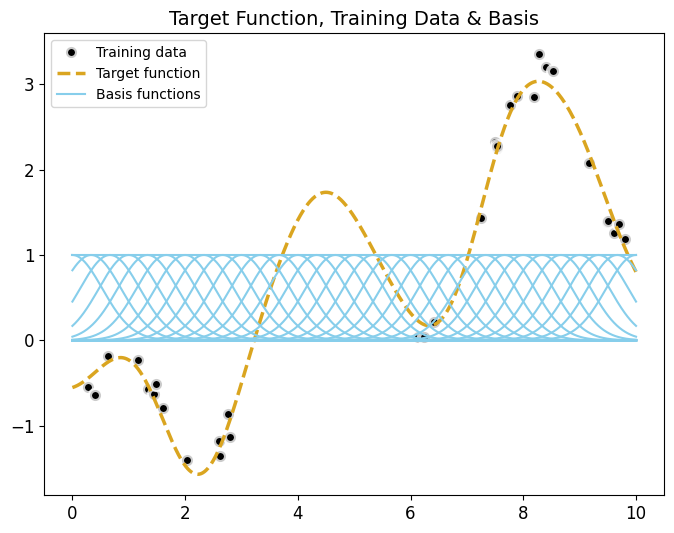

In [ ]:
# Basis - create generator instance and compute the basis matrices for all 3 data sets
# Note that because we use a "bias" function, we need N-1 Gaussians to make the
# basis "complete" (i.e. for M=N)
#
N_train = len(x_train)
N_val = len(x_val)
radius_model = radius_gen * 0.75
centres = np.linspace(generator.x_min, generator.x_max, N_train - 1)
basis = setup.RBFGenerator(centres, width=radius_model, bias=True)
M = basis.M
#
PHI_train = basis.evaluate(x_train)
PHI_val = basis.evaluate(x_val)
PHI_test = basis.evaluate(x_test)
#
interest = ["N_train", "N_val", "N_test", "sigma", "sigma_2",
            "M", "radius_gen", "radius_model"]
setup.tabulate_locals(locals(), interest)
#
setup.plot_regression(x_train, y_train, x_test, y_test, basis_test=PHI_test,
                      title="Target Function, Training Data & Basis", legend=True)


# 1. Penalised Least Squares

A flexible basis can fit noisy observations too closely. Penalised least squares controls that flexibility by shrinking the weights according to a regularisation parameter $\lambda$.

The first comparison examines three values of $\lambda$: near-zero regularisation, moderate regularisation, and strong regularisation. The plots and RMS errors show the trade-off between fitting observed data and generalising across the full input range.

In [ ]:
## FIT_PLS ##

def fit_pls(PHI, y, lam):
    # The function first checks to see whether lambda is 0
    # This allows the function to short-cut and not calculate PHI.T
    if lam == 0:
        # If lambda is 0, then PLS is just least squares
        return np.linalg.lstsq(PHI, y)[0]
    else:
        # Else identity matrix (M, M)
        M = PHI.shape[1]
        Im = np.identity(M)
        
        # Return the PLS estimate using the formula
        return np.linalg.inv((PHI.T @ PHI) + (lam * Im)) @ PHI.T @ y
    
 

### Compare Regularisation Strengths

`assess_predictor` fits one model, evaluates it on both the training observations and the noiseless reference curve, and plots the resulting function. The next cells compare three regularisation strengths and collect their RMS errors in a compact table.

Near-zero regularisation is expected to overfit the noise, while strong regularisation may underfit. Moderate regularisation should give a smoother function, although the missing interval remains difficult because no observations constrain it.

In [ ]:
## FITTING & GRAPHING FUNCTION


def assess_predictor(model_rbf, lamb, x__train, y__train, x__test, y__test):
    # Calculate PHI for the train and test set using basis.evaluate() as shown in the start demo
    PHI_Train = model_rbf.evaluate(x__train)
    PHI_Test = model_rbf.evaluate(x__test)

    # Calculate the PLS weights by fitting the training data
    PLS_Weight = fit_pls(PHI_Train, y__train, lamb)

    # Calculate the predictions
    f_train = PHI_Train @ PLS_Weight
    f_test = PHI_Test @ PLS_Weight

    # Print the title and plot the prediction against the actual data
    setup.plot_regression(x__train, y__train, x__test, y__test, f_test, legend = "legend", title = f"Model: Lambda = {lamb}")

    # Calcualte the errors between the target and the prediction
    error_train = setup.error_rms(y__train, f_train)
    error_test = setup.error_rms(y__test, f_test)

    # Return our errors
    return error_train, error_test


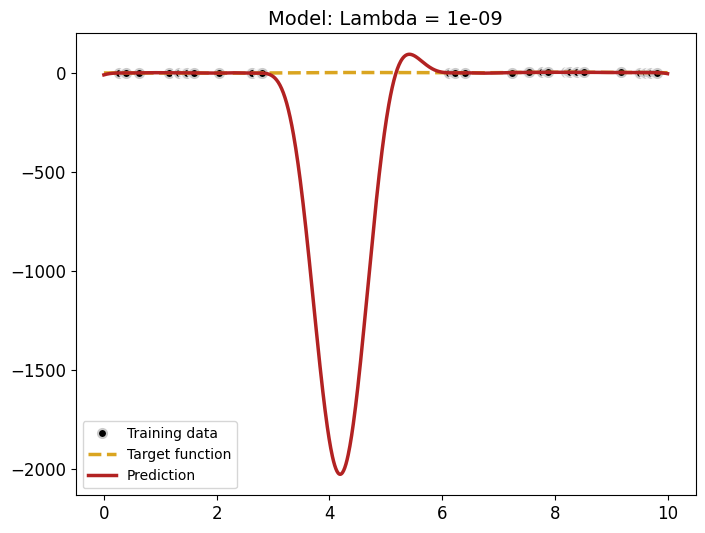

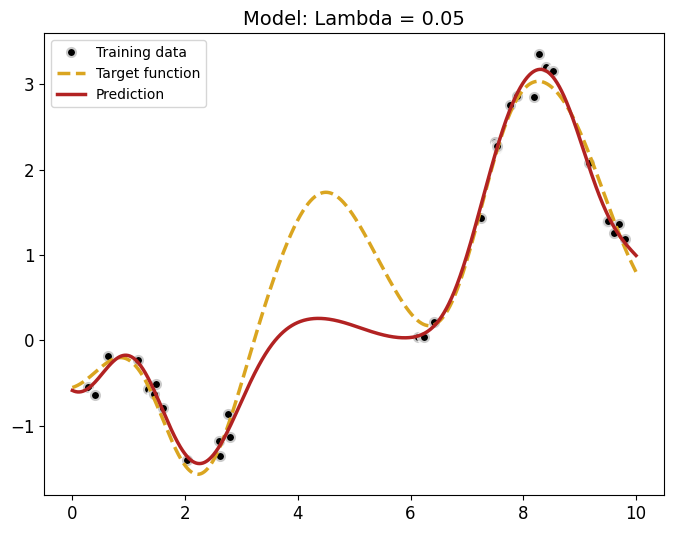

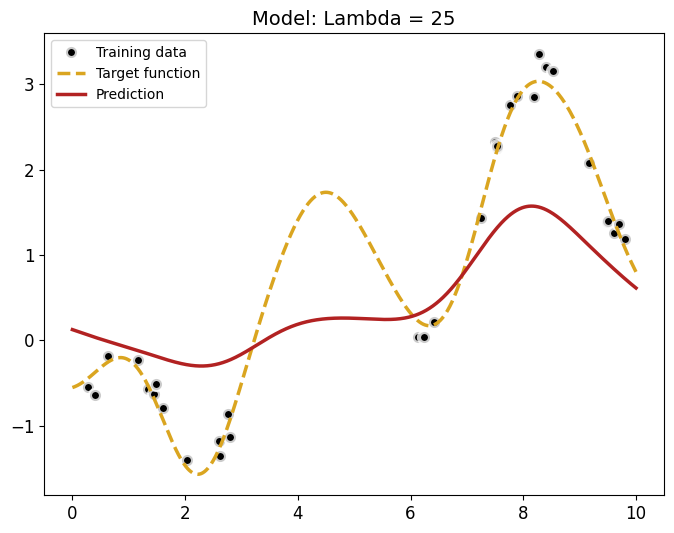

In [ ]:
# Add code to plot the requested graphs for lambda_value=1e-9, 0.05 and 25 respectively,
# while simultaneously compiling a table of errors

# Call assess_predictor on 3 different values of lambda and store the errors in separate variables
lamb1_train, lamb1_test = assess_predictor(basis, 1e-9, x_train, y_train, x_test, y_test)
lamb2_train, lamb2_test = assess_predictor(basis, 0.05, x_train, y_train, x_test, y_test)
lamb3_train, lamb3_test = assess_predictor(basis, 25, x_train, y_train, x_test, y_test)


In [ ]:
# Define table
table = [
    ["lambda=1e-9", round(lamb1_train, 5), round(lamb1_test, 5)],
    ["lambda=0.05", round(lamb2_train, 5), round(lamb2_test, 5)],
    ["lambda=25", round(lamb3_train, 5), round(lamb3_test, 5)]
]

# Set headers
headers = ["Lambda", "Train RMSE", "Test RMSE"]

# Call tabulate_neatly
setup.tabulate_neatly(table, headers, "PLS Errors for Different Lambda Values")

PLS Errors for Different Lambda Values

Lambda,Train RMSE,Test RMSE
lambda=1e-9,0.05958,566.227
lambda=0.05,0.10798,0.57342
lambda=25,0.89022,0.89768


# 2. Bayesian Model Selection

Bayesian linear regression places a Gaussian prior over the weights and combines it with the Gaussian observation model. This produces both a posterior mean and a posterior covariance, rather than a single fitted weight vector.

The section first checks that the posterior mean agrees with penalised least squares under the relationship $\lambda = \alpha\sigma^2$. It then evaluates the marginal likelihood, which balances data fit against model complexity.

In [ ]:
## POSTERIOR ##

def compute_posterior(PHI, y, alpha, sigma_squared):
    # Create an identity matrix with shape (M, M)
    M = PHI.shape[1]
    Im = np.identity(M)

    # Calculate Mu using the formula
    Mu = np.linalg.inv((PHI.T @ PHI) + (sigma_squared * alpha * Im)) @ PHI.T @ y

    # Calculate Sigma using the formula
    Sigma = sigma_squared * np.linalg.inv((PHI.T @ PHI) + (sigma_squared * alpha * Im))
    
    # Return Mu and Sigma
    return Mu, Sigma


# check consistency
def check_consistency(PHI, y, alpha, sigma_squared):
    # Calculate lambda from identity
    lam = alpha * sigma_squared

    # Calculate weights vector for PLS
    w = fit_pls(PHI, y, lam)

    # Calculate Mu and Sigma from our posterior
    Mu, Sigma = compute_posterior(PHI, y, alpha, sigma_squared)

    # Compare if the weights and Mu are the same
    if np.allclose(w, Mu):
        # If so return consistent
        return "Consistent"
    else:
        # If not, return not consistent
        return "Not Consistent"

# Call the check consistency function with arbitrary value of alpha
check_consistency(PHI_train, y_train, 0.1, sigma_2)




'Consistent'

### Posterior And Marginal Likelihood

For basis matrix $\mathbf{\Phi}$, targets $\mathbf{y}$, prior precision $\alpha$, and noise variance $\sigma^2$, the posterior mean and covariance are computed from the corresponding Gaussian linear model.

The marginal likelihood integrates over the unknown weights:

$$p(\mathbf{y}|\alpha, \sigma^2) = (2\pi)^{-N/2}|\sigma^2\mathbf{I} + \alpha^{-1}\mathbf{\Phi}\mathbf{\Phi}^{\top}|^{-1/2}
\exp\left\{-\frac{1}{2}\mathbf{y}^{\top}(\sigma^2\mathbf{I} + \alpha^{-1}\mathbf{\Phi}\mathbf{\Phi}^{\top})^{-1}\mathbf{y}\right\}.$$

The implementation works with the log density directly for numerical stability. An optional Woodbury-identity version expresses the same calculation through an $M \times M$ matrix, which is valuable when the number of basis functions is smaller than the number of observations.

In [ ]:
## MARGINAL LIKELIHOOD ##
import scipy.stats as stats

def compute_log_marginal(PHI, y, alph, s2):
    # Ensure y is a 1D array
    y = np.asarray(y).flatten()
    # Create an identity matrix with the shape (N, N)
    N = y.shape[0]   
    In = np.identity(N)

    # Calculate the NxN covariance using the formula
    Cov = s2 * In + (1/alph) * (PHI @ PHI.T)

    # Calcualte an empty matrix of zeros for our mean estimate
    Mean = np.zeros(N)

    # Return the log marginal likelihood
    return stats.multivariate_normal.logpdf(y, mean=Mean, cov=Cov, allow_singular=True)



In [ ]:
## MARGINAL LIKELIHOOD ##


# Marginal Likelihood:
# p(y|alpha, s2) = (2pi)^(N/2)|(s2)I+alpha^(-1)PhiPhi.T|^(-0.5)exp{-0.5 y.T(s2)I+alpha^(-1)PhiPhi.T)(^-1)y}

# Difficult arrises when trying to invert:
# (s2)I+alpha^(-1)PhiPhi.T

# Woodbury identity states:
# (A+UCV)^(-1) = A^(-1) - A^(-1)U(C^-1+VA^-1U)^(-1)VA^(-1)

# Use this and set:
# A = (s2)I
# U = Phi
# C = alpha^(-1)I
# V = Phi.T
# Wdby = (A+UCV)

# Re-write Marginal Likelihood:
# p(y|alpha, s2) = (2pi)^(N/2)|Wdby|^(-0.5)exp{-0.5 y.T(Wdby)(^-1)y}

# Take logs to find Log Marginal Likelihood:
# log p(y|alph, s2) = -0.5 * [N log(2pi) + log|Wdby| + y^T ((Wdby)^{-1} y]


def compute_log_marginal_advanced(PHI, y, alph, s2):
    # Ensure y is a 1D array
    y = np.asarray(y).flatten()
    
    # Calculate N and M
    N = y.shape[0]
    M = PHI.shape[1]

    # Create our identity matrices
    Im = np.identity(M)
    In = np.identity(N)

    # Set our variabls for the Woodbury identity
    A = s2 * In
    U = PHI
    C = (1/alph) * Im
    V = PHI.T

    # Calcualate the inverse of our variables
    AInv = np.linalg.inv(A)
    CInv = np.linalg.inv(C)

    # Define our Wdby variable
    Wdby = (s2) * In + alph**(-1) * PHI @ PHI.T

    # Use the woodbury identity to calculate the inverse
    WdbyInv = AInv - AInv @ U @ np.linalg.inv(CInv + V @ AInv @ U) @ V @ AInv

    # Calculate the determinant from our Wdby variable
    det_Wdby = np.linalg.det(Wdby)

    # Calculate log marginal likelihood
    lml = -0.5 * (N * np.log(2*np.pi) + np.log(det_Wdby) + y.T @ WdbyInv @ y)

    return lml



In [ ]:
# Extra consistency check to ensure both LML functions return the same result
def check_log_marg_consistency(PHI, y, alph, s2):

    log_marg = compute_log_marginal(PHI, y, alph, s2)
    print(log_marg)
    log_marg_adv = compute_log_marginal_advanced(PHI, y, alph, s2)
    print(log_marg_adv)

    # Compare if the log_marg values are the same
    if np.allclose(log_marg, log_marg_adv, atol=1e-5):
        # If so return consistent
        return "Consistent"
    else:
        # If not, return not consistent
        return "Not Consistent"

# Call the check consistency function with arbitrary value of alpha
check_log_marg_consistency(PHI_train, y_train, 0.1, sigma_2)

-20.27881115473855
-20.278811154819106


'Consistent'

### Sweep Hyperparameters And Compare Evidence

The following experiment evaluates a logarithmic range of regularisation values, from $10^{-6}$ to $10^4$. For each value it records training, validation, and test RMS error, as well as negative log marginal likelihood on the training set and on the combined training and validation data.

The curves answer different questions:

- training error measures fit to the observations used for learning;
- validation error estimates performance on held-out noisy observations;
- test error measures recovery of the known noiseless target across the whole domain;
- negative log marginal likelihood trades data fit against the complexity supported by the prior.

The combined-data evidence is used to select `best_alpha`, after which the posterior mean is evaluated on the full test grid.

In [ ]:
# Calculate the error for the train, test and validation sets and
# the negative log marginal-likelihood on the train set and combined
# train and validation sets ... all for a range of lambda

# Compute the relevant errors:

# Calculate Lambda values
v = np.linspace(-6, 4, 100)
lam_vals = 10**v

def calc_error(PHI, lam, PLS_W, y):
    # Calculate the predictions
    f = PHI @ PLS_Weight

    # Calcualte the errors between the target and the prediction
    error = setup.error_rms(y, f)

    # Return our errors
    return error

# Setup arrays for our errors
train_error = []
val_error = []
test_error = []

# Calculate the errors by looping through lambda values
for l in lam_vals:
    # Calculate the PLS weights by fitting the training data
    PLS_Weight = fit_pls(PHI_train, y_train, l)
    # Calculate errrs
    train_error.append(calc_error(PHI_train, l, PLS_Weight, y_train))
    val_error.append(calc_error(PHI_val, l, PLS_Weight, y_val))
    test_error.append(calc_error(PHI_test, l, PLS_Weight, y_test))

# Compute the (negative log) marginal likelihood

# Compute alpha
alpha_vals = lam_vals/sigma_2

# Create the train/val set
x_tr_va = np.concatenate([x_train, x_val])
y_tr_va = np.concatenate([y_train, y_val])
PHI_tr_va = basis.evaluate(x_tr_va)

# Set up arrays for our log marginal likelihood values
train_lml = []
tr_va_lml = []

# Compute Negative Log Marginal Likelihood
for a in alpha_vals:
    train_lml.append(-(compute_log_marginal(PHI_train, y_train, a, sigma_2)))
    tr_va_lml.append(-(compute_log_marginal(PHI_tr_va, y_tr_va, a, sigma_2)))

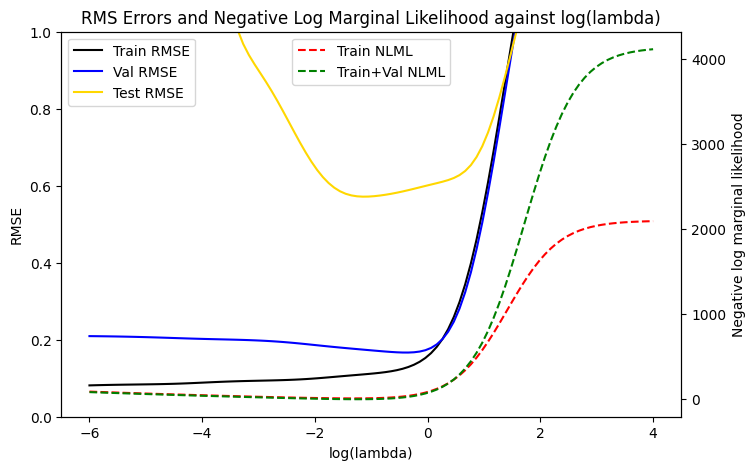

Test Errors at Minimum of Error Curves

Curve,Test Error
Min of train error,20.2778
Min of val error,0.588476
Min of test error,0.571599
Min of train_lml error,0.574858
Min of tr_va_lmlt error,0.572496


Value of Alpha that minimises the negative marginal likelihood curve on the combined training and validation data:
2.4848045


In [ ]:
# Plot the curves:

import matplotlib.pyplot as plt

# Set up plot
fig, ax1 = plt.subplots(figsize = (8,5))

# Primary axis with solid colour RMSE values
ax1.plot(v, train_error, color = "black", label = "Train RMSE")
ax1.plot(v, val_error, color = "blue", label = "Val RMSE")
ax1.plot(v, test_error, color = "gold", label = "Test RMSE")
ax1.set_xlabel("log(lambda)")
ax1.set_ylabel("RMSE")
ax1.set_ylim(0,1)
ax1.legend(loc = "upper left")

# Secondary axis with dashed log marginal likelihood curves
ax2 = ax1.twinx()
ax2.plot(v, train_lml, color = "red", label = "Train NLML", linestyle = "dashed")
ax2.plot(v, tr_va_lml, color = "green", label = "Train+Val NLML", linestyle = "dashed")
ax2.set_ylabel("Negative log marginal likelihood")
ax2.legend(loc = "upper center")

plt.title("RMS Errors and Negative Log Marginal Likelihood against log(lambda)")

plt.show()

# Define table
table_errors = [
    ["Min of train error", round(test_error[train_error.index(min(train_error))], 7)],
    ["Min of val error", round(test_error[val_error.index(min(val_error))], 7)],
    ["Min of test error", round(test_error[test_error.index(min(test_error))], 7)],
    ["Min of train_lml error", round(test_error[train_lml.index(min(train_lml))], 7)],
    ["Min of tr_va_lmlt error", round(test_error[tr_va_lml.index(min(tr_va_lml))], 7)]
]

# Set headers
headers_errors = ["Curve", "Test Error"]

# Call tabulate_neatly
setup.tabulate_neatly(table_errors, headers_errors, title="Test Errors at Minimum of Error Curves")

# Find the best alpha value:
print("Value of Alpha that minimises the negative marginal likelihood curve on the combined training and validation data:")
marg_best_alph = lam_vals[tr_va_lml.index(min(tr_va_lml))]/sigma_2
print(round(marg_best_alph, 7))

### Posterior Mean Predictor

Using the value of $\alpha$ selected from the combined-data marginal likelihood, the notebook computes the posterior mean weights and evaluates the resulting predictor over the full test grid.

This model should track the target well where observations are available. In the missing interval, the prediction is an extrapolation and should be interpreted alongside its uncertainty rather than on its mean alone.

In [ ]:
# Code to calculate posterior mean weights and corresponding predictor

# Call the compute posterior function to calculate Mu and Sigma with the best alpha value on the combined training and validation set
Mu, Sigma = compute_posterior(PHI_tr_va, y_tr_va, marg_best_alph, sigma_2)

# Predict on the test set
f_test = PHI_test @ Mu

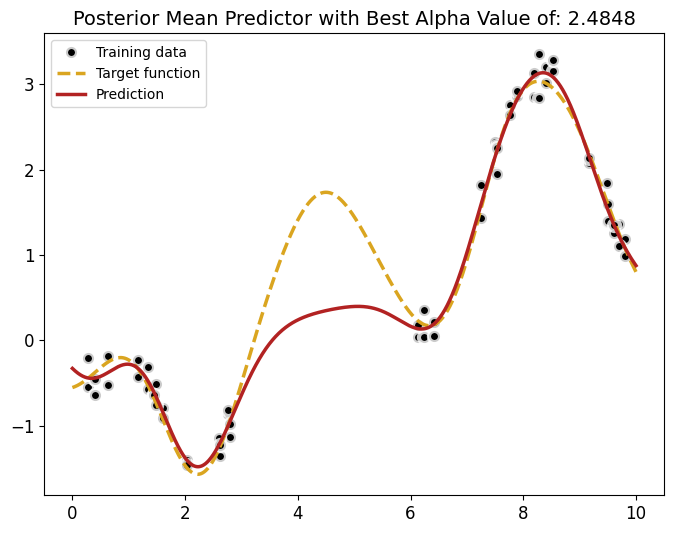

In [ ]:
# Visualise the predictor

# Call plot function
setup.plot_regression(x_tr_va, y_tr_va, x_test, y_test, f_test, legend = "legend", title = f"Posterior Mean Predictor with Best Alpha Value of: {round(marg_best_alph,4)}")

# 3. Predictive Uncertainty And Decisions

A Bayesian prediction is a distribution. At each input, the posterior covariance determines how uncertain the fitted weights are, while the observation noise contributes an irreducible variance term.

The next cells visualise one-standard-deviation predictive intervals and then use them to make a simple risk-aware decision: predict only when the expected financial return is positive.

In [ ]:
# Compute the predictive variance

# Calculate the predicted variance and standard deviation using Sigma from our compute posterior function earlier
pred_var = sigma_2 + np.diag(PHI_test @ Sigma @ PHI_test.T)
pred_std = np.sqrt(pred_var)

# Ensure f_test is a 1D array
f_test = np.squeeze(f_test)

# Calculate the upper and lower bounds for +/- one std
ub = f_test + pred_std
lb = f_test - pred_std



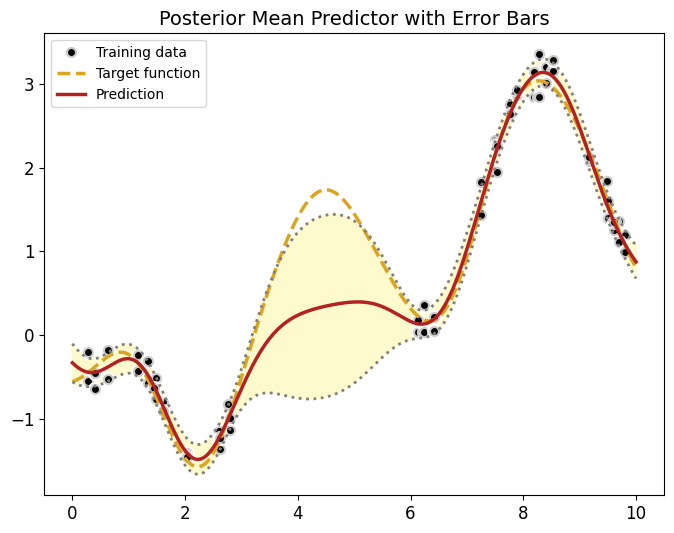

In [ ]:
# Plot the error bars

# Call the plotting function
setup.plot_regression(x_tr_va, y_tr_va, x_test, y_test, f_test, upper = ub, lower = lb, legend = "legend", title = f"Posterior Mean Predictor with Error Bars")

### Risk-Aware Prediction Policy

Suppose deployed predictions receive a reward of £10 when their absolute error is at most `threshold = 0.15`, and incur a cost of £20 otherwise. A prediction may also be declined at zero cost.

The policy estimates the probability of being within the threshold from the predictive Gaussian distribution. It predicts when the expected return is positive:

$$p_{accurate} = 2\Phi\left(\frac{threshold}{pred\_std}\right)-1,$$

$$E[return] = 10p_{accurate} - 20(1-p_{accurate}).$$

This turns uncertainty into an operational decision. The model is cautious where its posterior interval is wide, particularly in the region absent from the training data.

### Decision Policy: Explanation

The deployment setting is treated as noiseless, so the decision rule uses only uncertainty in the fitted weights. For each candidate input, the predictive standard deviation gives a Gaussian approximation to the error around the posterior mean.

The policy predicts when the expected reward exceeds the expected cost. This requires the probability of an absolute error no larger than the threshold to be greater than $20/(10+20)=2/3$. Otherwise it declines. The final cells apply the policy to the reference grid, report its outcomes, and visualise where predictions are accepted or declined.

In [ ]:
threshold = 0.15
reward_under = 10
cost_above = 20

from scipy.stats import norm

# Recalculate the predictive variance and std with 0 noise
s2 = 0
pred_var = s2 + np.diag(PHI_test @ Sigma @ PHI_test.T)
pred_std = np.sqrt(pred_var)

# Calculate the probability of the prediction landing within the threshold
p_accurate = 2 * norm.cdf(threshold/pred_std) - 1

# Calculate the expected reward of each prediction
E_return= (reward_under * p_accurate) - (cost_above * (1 - p_accurate))

# Determine whether or not to predict
predict_decision = E_return > 0


In [ ]:
# Apply your algorithm to the test set, and tabulate the relevant statistics

# Ensure y_test is a 1D array
y_test = np.squeeze(y_test)

# Calculate absolute errors on test set
abs_errors = np.abs(f_test - y_test)

# Extract only the indicies of the points that we want to predit on
predicted_indices = np.where(predict_decision)[0]

# Calculate how many predictions (out of 1,000) were made
num_predictions = len(predicted_indices)

# Calculate the number of predicted values that were rewarded for being within the threshold
num_rewarded = np.sum(abs_errors[predicted_indices] <= threshold)
# Calculate the number of predicted values that were charge for being outside the threshold
num_charged = np.sum(abs_errors[predicted_indices] > threshold)
# Calculate the percentage of predictions that were rewarded
percentage_rewarded = (num_rewarded / num_predictions * 100) if num_predictions > 0 else 0

# If the absolute error of the prediction is less or equal to the threshold, then assign reward, otherwise assign cost
rewards = np.where(abs_errors[predicted_indices] <= threshold, reward_under, -cost_above)

# Sum up all the rewards in the array
total_earnings = np.sum(rewards)

# , "/", len(y_test)


# Define table
table_decision = [
    ["Number of predictions made", num_predictions],
    ["Number rewarded", num_rewarded],
    ["Number charged", num_charged],
    ["Percentage rewarded", round(percentage_rewarded,2)],
    ["Total earnings (£)", total_earnings]
]

# Set headers
headers_decision = ["Metric", "Value"]

# Call tabulate_neatly
setup.tabulate_neatly(table_decision, headers_decision, title="Decision Algorithm Results")


# Algorithm earns around £4830 with just the training set instead of the combined training and validation set


Decision Algorithm Results

Metric,Value
Number of predictions made,690
Number rewarded,686
Number charged,4
Percentage rewarded,99.42
Total earnings (£),6780


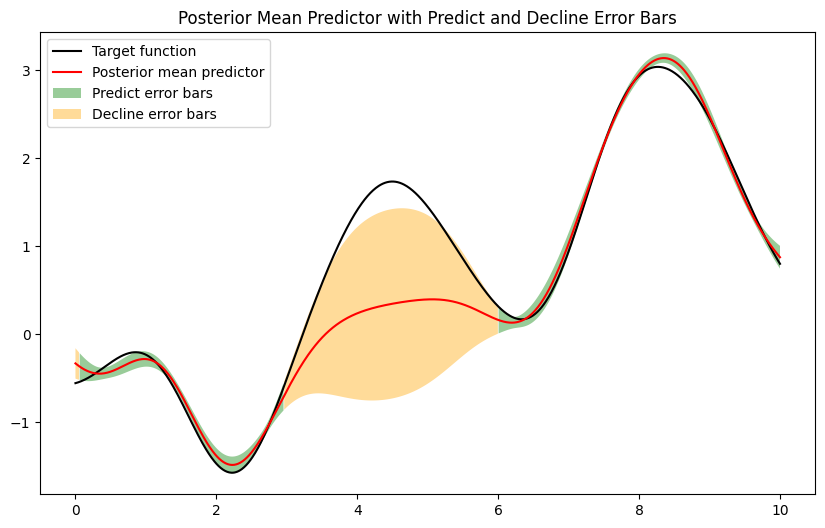

In [ ]:
# Visualise your algorithm's decision-making


import matplotlib.pyplot as plt

# Recalculate the upper and lower bounds with the new predicted std
ub = f_test + pred_std
lb = f_test - pred_std

# Ensure x_test is 1D array
x_test = np.squeeze(x_test)

# Set up plot
plt.figure(figsize=(10,6))

# Plot the target function and posterior mean predictor
plt.plot(x_test, y_test, 'k-', label="Target function")
plt.plot(x_test, f_test, 'r-', label="Posterior mean predictor")


# When predict decision is true plot the upper and lower bounds as green
plt.fill_between(x_test, ub, lb, where=predict_decision, facecolor='green', alpha=0.4, label="Predict error bars")

# When predict decision is false, plot the upper and lower bounds as orange
plt.fill_between(x_test, ub, lb, where=~predict_decision, facecolor='orange', alpha=0.4, label="Decline error bars")

# Insert legend, title and show plot
plt.legend()
plt.title("Posterior Mean Predictor with Predict and Decline Error Bars")
plt.show()
